In [1]:
import pandas as pd


In [2]:
df = pd.read_csv("food_messy_dataset1.csv")

In [3]:
df.head()

,order_id,restaurant_name,cuisine_type,meal_time,num_items,avg_item_price,discount_percent,delivery_distance_km,delivery_rating,customer_age,customer_gender,weekend,num_previous_orders,total_bill
0,1,Spice Garden,Indian,Lunch,3,180.5,10.0,2.3,4.5,28,Male,Yes,5.0,486.0
1,2,Pizza Palace,Italian,Dinner,2,350.0,0.0,5.1,3.8,34,Female,No,12.0,700.0
2,3,Burger Barn,American,Lunch,4,220.0,15.0,1.8,4.2,22,Male,Yes,2.0,748.0
3,4,Sushi Stop,Japanese,Dinner,5,410.0,5.0,7.2,4.9,41,Female,No,20.0,1947.5
4,5,Spice Garden,Indian,Breakfast,1,90.0,0.0,2.3,4.5,19,Male,No,0.0,90.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              200 non-null    int64  
 1   restaurant_name       200 non-null    object 
 2   cuisine_type          200 non-null    object 
 3   meal_time             199 non-null    object 
 4   num_items             199 non-null    object 
 5   avg_item_price        199 non-null    float64
 6   discount_percent      199 non-null    float64
 7   delivery_distance_km  199 non-null    float64
 8   delivery_rating       199 non-null    object 
 9   customer_age          199 non-null    object 
 10  customer_gender       198 non-null    object 
 11  weekend               199 non-null    object 
 12  num_previous_orders   199 non-null    float64
 13  total_bill            196 non-null    float64
dtypes: float64(5), int64(1), object(8)
memory usage: 22.0+ KB


In [5]:
df.shape

(200, 14)

In [6]:
df.dtypes

order_id                  int64
restaurant_name          object
cuisine_type             object
meal_time                object
num_items                object
avg_item_price          float64
discount_percent        float64
delivery_distance_km    float64
delivery_rating          object
customer_age             object
customer_gender          object
weekend                  object
num_previous_orders     float64
total_bill              float64
dtype: object

In [7]:
df[['num_items','delivery_rating','customer_age']] = df[['num_items','delivery_rating','customer_age']].apply(pd.to_numeric, errors='coerce')

In [8]:
df.dtypes

order_id                  int64
restaurant_name          object
cuisine_type             object
meal_time                object
num_items               float64
avg_item_price          float64
discount_percent        float64
delivery_distance_km    float64
delivery_rating         float64
customer_age            float64
customer_gender          object
weekend                  object
num_previous_orders     float64
total_bill              float64
dtype: object

In [9]:
df.isnull().sum()

order_id                0
restaurant_name         0
cuisine_type            0
meal_time               1
num_items               2
avg_item_price          1
discount_percent        1
delivery_distance_km    1
delivery_rating         2
customer_age            2
customer_gender         2
weekend                 1
num_previous_orders     1
total_bill              4
dtype: int64

In [10]:
for col in df.columns:
  print(f"{col}: {df[col].unique()}")

order_id: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200]
restaurant_name: ['Spice Garden' 'Pizza Palace' 'Burger Barn' 'Sushi Stop' 'Green Bowl'
 'Taco Town' 'Noodle Nest']
cuisine_type: ['Indian' 'Italian' 'American' 'Japanese' 'Heal

In [11]:
df['meal_time'] =df['meal_time'].fillna(df['meal_time'].mode()[0])
df['num_items'] = df['num_items'].fillna(df['num_items'].mean())

In [12]:
df[df['avg_item_price']<0]

,order_id,restaurant_name,cuisine_type,meal_time,num_items,avg_item_price,discount_percent,delivery_distance_km,delivery_rating,customer_age,customer_gender,weekend,num_previous_orders,total_bill
84,85,Pizza Palace,Italian,Dinner,5.0,-350.0,5.0,5.1,3.8,32.0,Male,Yes,10.0,1662.5


In [13]:
df=df[df['avg_item_price']>=0]
df = df[df['avg_item_price'] < 1000]
df = df[df['total_bill'] < 10000]

In [14]:
df['discount_percent'] = df['discount_percent'].fillna(df['discount_percent'].mean())
df['delivery_distance_km'] = df['delivery_distance_km'].fillna(df['delivery_distance_km'].mean())
df['delivery_rating'] = df['delivery_rating'].fillna(df['delivery_rating'].mean())
df['customer_age'] = df['customer_age'].fillna(df['customer_age'].median())
df['customer_gender'] = df['customer_gender'].fillna(df['customer_gender'].mode()[0])
df['weekend'] = df['weekend'].fillna(df['weekend'].mode()[0])
df['num_previous_orders'] = df['num_previous_orders'].fillna(df['num_previous_orders'].mean())
df['total_bill'] = df['total_bill'].fillna(df['total_bill'].median())

In [15]:
df.isnull().sum()

order_id                0
restaurant_name         0
cuisine_type            0
meal_time               0
num_items               0
avg_item_price          0
discount_percent        0
delivery_distance_km    0
delivery_rating         0
customer_age            0
customer_gender         0
weekend                 0
num_previous_orders     0
total_bill              0
dtype: int64

In [16]:
df=df.drop('order_id',axis=1)

In [17]:
df.head()

,restaurant_name,cuisine_type,meal_time,num_items,avg_item_price,discount_percent,delivery_distance_km,delivery_rating,customer_age,customer_gender,weekend,num_previous_orders,total_bill
0,Spice Garden,Indian,Lunch,3.0,180.5,10.0,2.3,4.5,28.0,Male,Yes,5.0,486.0
1,Pizza Palace,Italian,Dinner,2.0,350.0,0.0,5.1,3.8,34.0,Female,No,12.0,700.0
2,Burger Barn,American,Lunch,4.0,220.0,15.0,1.8,4.2,22.0,Male,Yes,2.0,748.0
3,Sushi Stop,Japanese,Dinner,5.0,410.0,5.0,7.2,4.9,41.0,Female,No,20.0,1947.5
4,Spice Garden,Indian,Breakfast,1.0,90.0,0.0,2.3,4.5,19.0,Male,No,0.0,90.0


In [18]:
df.corr(numeric_only=True)['total_bill'].sort_values(ascending=False)

total_bill              1.000000
num_items               0.702462
avg_item_price          0.687880
delivery_distance_km    0.424989
customer_age            0.218387
num_previous_orders     0.204734
discount_percent        0.171712
delivery_rating         0.161383
Name: total_bill, dtype: float64

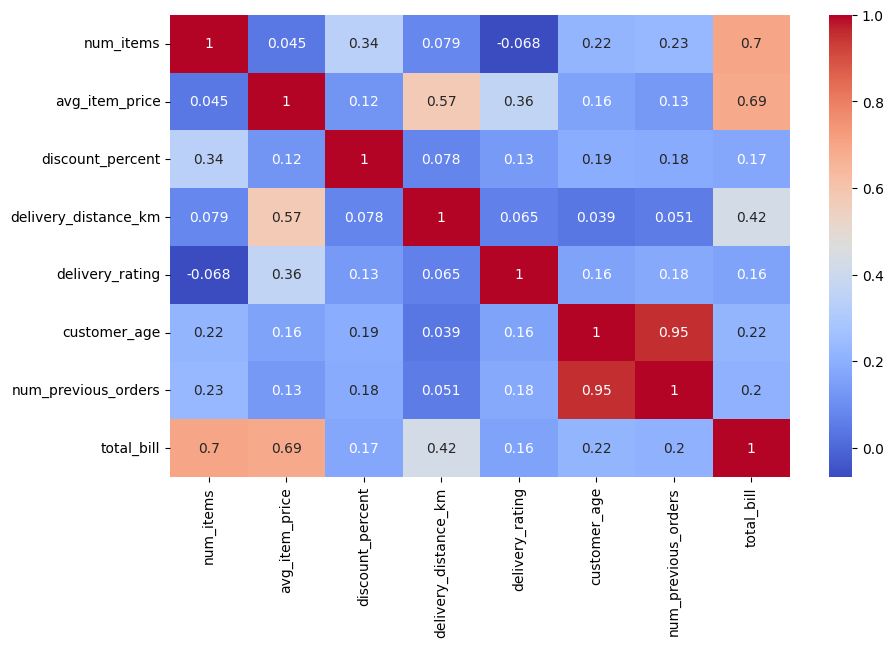

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [20]:
cols = ['customer_gender', 'cuisine_type', 'meal_time']

for col in cols:
    df[col] = df[col].str.lower()

In [21]:
for col in df.columns:
  print(f"{col}: {df[col].unique()}")

restaurant_name: ['Spice Garden' 'Pizza Palace' 'Burger Barn' 'Sushi Stop' 'Green Bowl'
 'Taco Town' 'Noodle Nest']
cuisine_type: ['indian' 'italian' 'american' 'japanese' 'healthy' 'mexican' 'chinese']
meal_time: ['lunch' 'dinner' 'breakfast']
num_items: [3. 2. 4. 5. 1. 6.]
avg_item_price: [180.5 350.  220.  410.   90.  280.  160.  195. ]
discount_percent: [10.  0. 15.  5. 20.]
delivery_distance_km: [2.3        5.1        1.8        7.2        3.5        4.
 6.3        4.28756477]
delivery_rating: [4.5       3.8       4.2       4.9       4.7       4.1       4.
 4.3171875]
customer_age: [28. 34. 22. 41. 19. 27. 35. 30. 25. 38. 29. 44. 31. 23. 26. 33. 40. 36.
 21. 45. 32. 39. 43. 24. 37. 48. 20. 47. 46. 42.]
customer_gender: ['male' 'female']
weekend: ['Yes' 'No']
num_previous_orders: [ 5.         12.          2.         20.          0.          8.
 15.          7.          3.         11.          9.         25.
 18.          1.          6.         14.         22.          4.
 16.      

In [22]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
cols = ['customer_gender', 'weekend']

for col in cols:
    df[col] = le.fit_transform(df[col])

In [23]:
df = pd.get_dummies(df, columns=['restaurant_name','cuisine_type','meal_time'],
                    drop_first=True)

In [24]:
# Total cost before discount
df['total_items_price'] = df['num_items'] * df['avg_item_price']

# Discount amount
df['discount_amount'] = df['total_items_price'] * (df['discount_percent'] / 100)

In [25]:
from sklearn.model_selection import train_test_split

x=df.drop(['total_bill'],axis=1)
y=df['total_bill']

In [26]:
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [28]:
y_pred = model.predict(x_test)

In [29]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse=root_mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2= r2_score(y_test, y_pred)

print("MAE: ",mae)
print("R2_score: ",r2)
print("MSE: ",mse)
print('RMSE: ',rmse)

MAE:  0.06799189436939293
R2_score:  0.9999997682390315
MSE:  0.0344952340266669
RMSE:  0.18572892619801284


In [30]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']